# 🎓 Student Academic Performance & Pass Prediction
## End-to-End Machine Learning Pipeline & Hyperparameter Optimization

### 📌 Project Overview
Academic institutions face challenges identifying students at risk of academic failure early enough to provide targeted intervention. This project creates an end-to-end Machine Learning pipeline to predict student pass/fail outcomes (`Pass = 1` vs `Pass = 0`) based on demographic data, study habits, attendance, and continuous assessment scores.

### 🎯 Key Objectives:
1. **Automated Preprocessing**: Impute missing values, scale numerical features, and encode categorical variables inside scikit-learn `Pipeline` to prevent data leakage.
2. **Multi-Model Benchmarking**: Compare 6 distinct classification algorithms across Accuracy, Precision, Recall, F1-Score, and ROC-AUC.
3. **Hyperparameter Tuning**: Optimize the top-performing ensemble architecture using 5-Fold Stratified `GridSearchCV`.
4. **Feature Interpretability**: Quantify key predictors of academic success.
5. **Model Serialization**: Save the production inference pipeline for downstream batch and real-time inference.

In [5]:
# Step 1: Import Core Libraries
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

# Scikit-Learn Modeling & Evaluation
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    confusion_matrix, classification_report, roc_curve, ConfusionMatrixDisplay
)

# Plotting Configuration
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['font.size'] = 11

print("Libraries imported successfully.")

Libraries imported successfully.


## 1. 📂 Data Ingestion & Overview
We load the raw student performance dataset from `../data/raw/student_performance.csv` and inspect its structure, dimensions, and types.

In [6]:
# Step 2: Load Dataset
data_path = os.path.join("..", "data", "raw", "student_performance.csv")
df = pd.read_csv(data_path)

print(f"Dataset Shape: {df.shape[0]} rows, {df.shape[1]} columns\n")
print("First 5 records:")
df.head()

Dataset Shape: 300 rows, 11 columns

First 5 records:


,StudentID,Age,Gender,Department,StudyHours,Attendance,AssignmentScore,PreviousExamScore,PracticeTestScore,FinalMarks,Pass
0,S001,24,Male,Engineering,1.0,81.7,60.0,59.0,57.0,54.6,1
1,S002,21,Male,Engineering,2.0,84.0,46.0,55.0,45.0,51.6,1
2,S003,22,Male,Engineering,5.0,52.5,66.0,70.0,54.0,58.3,1
3,S004,24,Female,Engineering,6.2,82.8,73.0,73.0,63.0,69.8,1
4,S005,20,Male,Mathematics,7.8,52.2,59.0,61.0,48.0,61.3,1


In [7]:
# Dataset Information and Summary Statistics
print("Dataset Summary Info:")
df.info()

print("\nStatistical Summary:")
df.describe(include='all')

Dataset Summary Info:
<class 'pandas.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   StudentID          300 non-null    str    
 1   Age                300 non-null    int64  
 2   Gender             299 non-null    str    
 3   Department         299 non-null    str    
 4   StudyHours         298 non-null    float64
 5   Attendance         298 non-null    float64
 6   AssignmentScore    299 non-null    float64
 7   PreviousExamScore  299 non-null    float64
 8   PracticeTestScore  299 non-null    float64
 9   FinalMarks         300 non-null    float64
 10  Pass               300 non-null    int64  
dtypes: float64(6), int64(2), str(3)
memory usage: 25.9 KB

Statistical Summary:


,StudentID,Age,Gender,Department,StudyHours,Attendance,AssignmentScore,PreviousExamScore,PracticeTestScore,FinalMarks,Pass
count,300,300.000000,299,299,298.000000,298.000000,299.000000,299.000000,299.000000,300.000000,300.000000
unique,300,NaN,2,5,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,S001,NaN,Female,Engineering,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,1,NaN,152,63,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,21.040000,NaN,NaN,5.492617,74.843960,58.200669,61.143813,54.033445,61.825333,0.793333
std,NaN,2.014596,NaN,NaN,2.363915,14.962237,13.487996,13.624989,12.180365,12.972472,0.405591
min,NaN,18.000000,NaN,NaN,1.000000,50.000000,30.000000,28.000000,26.000000,34.100000,0.000000
25%,NaN,19.000000,NaN,NaN,3.600000,61.300000,48.000000,52.000000,45.000000,53.075000,1.000000
50%,NaN,21.000000,NaN,NaN,5.600000,75.650000,58.000000,61.000000,54.000000,62.100000,1.000000
75%,NaN,23.000000,NaN,NaN,7.600000,87.875000,67.000000,71.000000,63.000000,71.525000,1.000000


## 2. 🔍 Data Quality Check & Missing Value Analysis
We verify the integrity of the data and examine any missing values across numerical and categorical columns.

In [4]:
# Check Missing Values and Duplicates
missing_df = pd.DataFrame({
    'Missing Values': df.isnull().sum(),
    'Percentage (%)': np.round((df.isnull().sum() / len(df)) * 100, 2)
})
print("Missing Value Analysis:")
display(missing_df[missing_df['Missing Values'] > 0])

print(f"\nDuplicate Rows Detected: {df.duplicated().sum()}")

Missing Value Analysis:


,Missing Values,Percentage (%)
Gender,1,0.33
Department,1,0.33
StudyHours,2,0.67
Attendance,2,0.67
AssignmentScore,1,0.33
PreviousExamScore,1,0.33
PracticeTestScore,1,0.33



Duplicate Rows Detected: 0


## 3. 📊 Exploratory Data Analysis (EDA)
We visualize target distribution, feature correlations, and key performance drivers.

C:\Users\User\AppData\Local\Temp\ipykernel_10108\508897439.py:12: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=20)


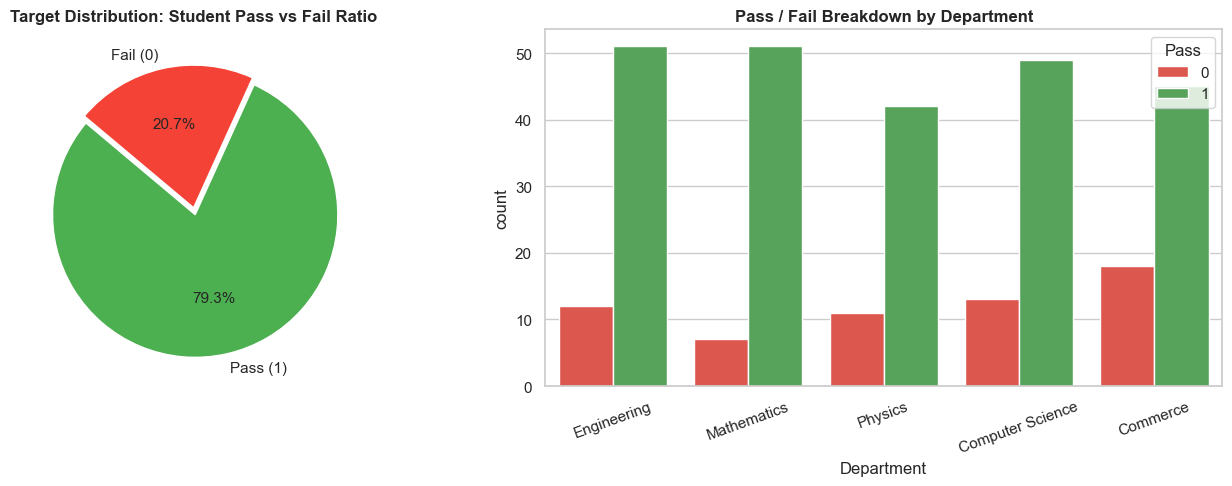

In [5]:
# Target Class Balance & Department Distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Target Balance
pass_counts = df['Pass'].value_counts()
axes[0].pie(pass_counts, labels=['Pass (1)', 'Fail (0)'], autopct='%1.1f%%', colors=['#4CAF50', '#F44336'], explode=(0.05, 0), startangle=140)
axes[0].set_title('Target Distribution: Student Pass vs Fail Ratio', fontsize=12, fontweight='bold')

# Department Count
sns.countplot(data=df, x='Department', hue='Pass', ax=axes[1], palette=['#F44336', '#4CAF50'])
axes[1].set_title('Pass / Fail Breakdown by Department', fontsize=12, fontweight='bold')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=20)
plt.tight_layout()
plt.show()

C:\Users\User\AppData\Local\Temp\ipykernel_10108\3191736030.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Pass', y='StudyHours', ax=axes[0, 0], palette=['#F44336', '#4CAF50'])
C:\Users\User\AppData\Local\Temp\ipykernel_10108\3191736030.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0, 0].set_xticklabels(['Fail (0)', 'Pass (1)'])
C:\Users\User\AppData\Local\Temp\ipykernel_10108\3191736030.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Pass', y='Attendance', ax=axes[0, 1], palette=['#F44336', '#4CAF50'])
C:\Users\User\AppData\Local\Temp\ipykernel_10108\3191736030.p

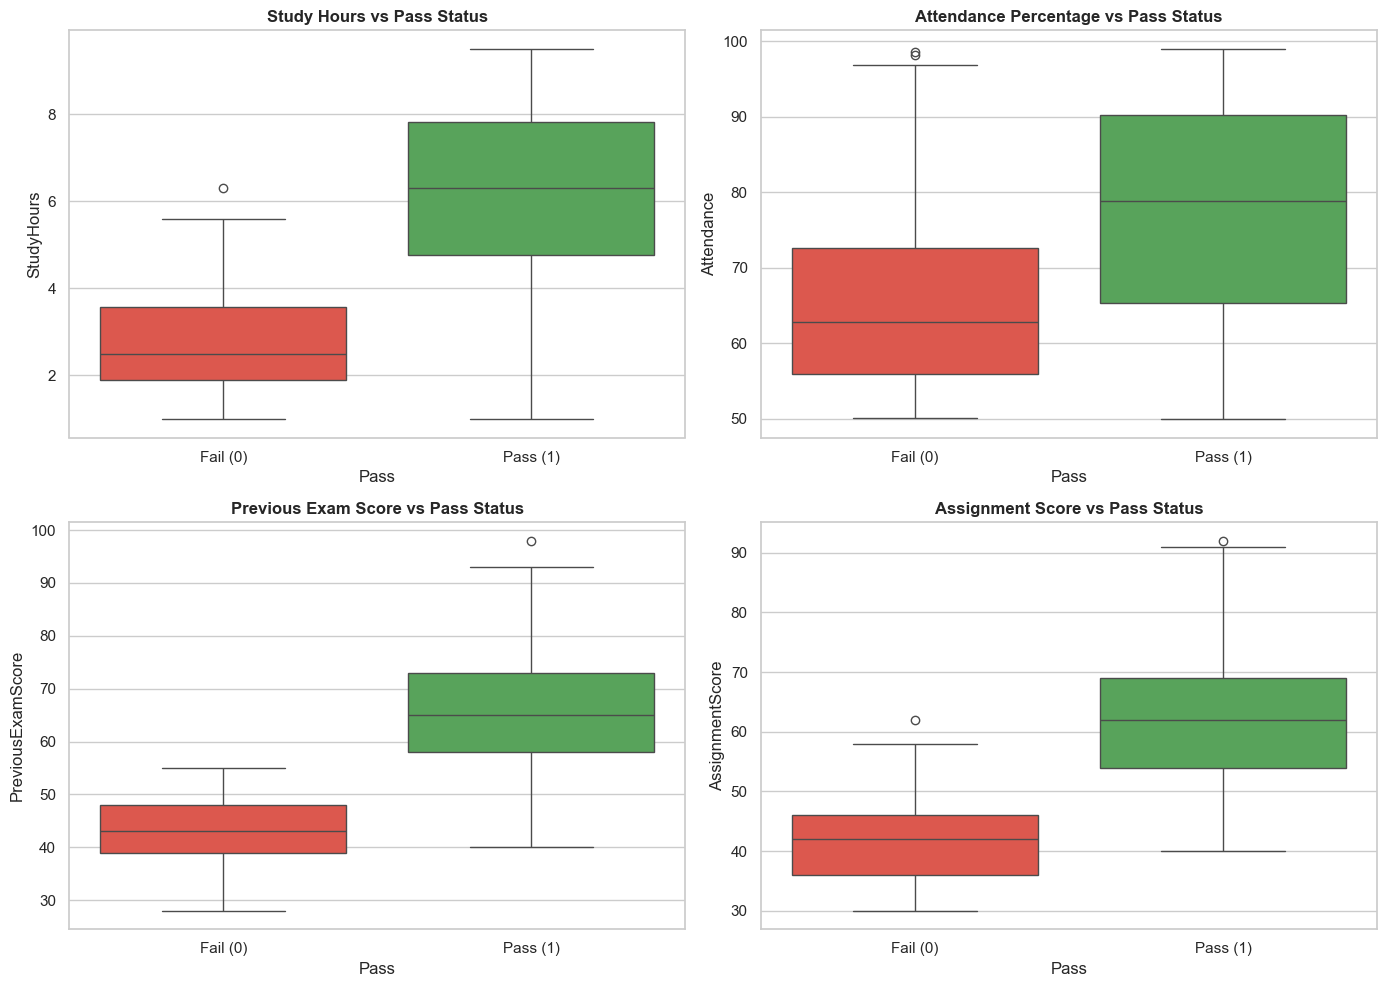

In [6]:
# Continuous Feature Relationships vs Academic Outcome
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sns.boxplot(data=df, x='Pass', y='StudyHours', ax=axes[0, 0], palette=['#F44336', '#4CAF50'])
axes[0, 0].set_title('Study Hours vs Pass Status', fontweight='bold')
axes[0, 0].set_xticklabels(['Fail (0)', 'Pass (1)'])

sns.boxplot(data=df, x='Pass', y='Attendance', ax=axes[0, 1], palette=['#F44336', '#4CAF50'])
axes[0, 1].set_title('Attendance Percentage vs Pass Status', fontweight='bold')
axes[0, 1].set_xticklabels(['Fail (0)', 'Pass (1)'])

sns.boxplot(data=df, x='Pass', y='PreviousExamScore', ax=axes[1, 0], palette=['#F44336', '#4CAF50'])
axes[1, 0].set_title('Previous Exam Score vs Pass Status', fontweight='bold')
axes[1, 0].set_xticklabels(['Fail (0)', 'Pass (1)'])

sns.boxplot(data=df, x='Pass', y='AssignmentScore', ax=axes[1, 1], palette=['#F44336', '#4CAF50'])
axes[1, 1].set_title('Assignment Score vs Pass Status', fontweight='bold')
axes[1, 1].set_xticklabels(['Fail (0)', 'Pass (1)'])

plt.tight_layout()
plt.show()

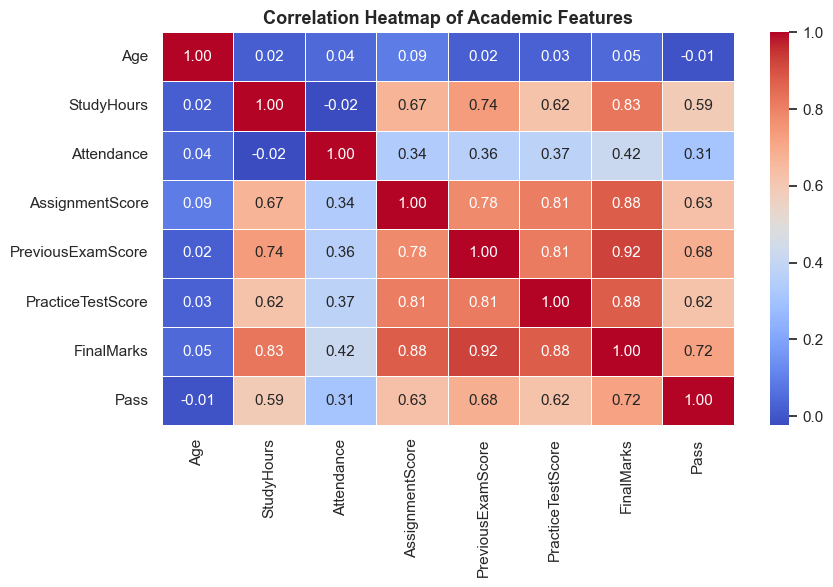

In [7]:
# Correlation Heatmap for Numerical Features
plt.figure(figsize=(9, 6))
numeric_cols = df.select_dtypes(include=np.number).columns
corr = df[numeric_cols].corr()
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap of Academic Features", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

## 4. ⚙️ Feature Selection & Stratified Train/Test Split
We define predictor features $X$ and outcome target $y$, then stratify 80% for training and 20% for testing.

In [8]:
# Define Input Features and Target
numeric_features = ['Age', 'StudyHours', 'Attendance', 'AssignmentScore', 'PreviousExamScore', 'PracticeTestScore']
categorical_features = ['Gender', 'Department']
feature_cols = numeric_features + categorical_features

X = df[feature_cols]
y = df['Pass']

# 80/20 Stratified Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print(f"Training Set: {X_train.shape[0]} samples (Pass rate: {y_train.mean()*100:.1f}%)")
print(f"Testing Set:  {X_test.shape[0]} samples (Pass rate: {y_test.mean()*100:.1f}%)")

Training Set: 240 samples (Pass rate: 79.2%)
Testing Set:  60 samples (Pass rate: 80.0%)


## 5. 🛠️ Scikit-Learn Preprocessing Pipeline Architecture
We encapsulate numeric transformation (Median Imputation + Standard Scaling) and categorical transformation (Mode Imputation + One-Hot Encoding) inside a `ColumnTransformer` to prevent data leakage during Cross-Validation.

In [9]:
# Build Modular Preprocessing Transformers
num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

cat_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer(transformers=[
    ('num', num_pipeline, numeric_features),
    ('cat', cat_pipeline, categorical_features)
])

print("Preprocessing ColumnTransformer constructed successfully.")

Preprocessing ColumnTransformer constructed successfully.


## 6. 🏆 Multi-Model Benchmark Comparison
We evaluate 6 core classification algorithms using 5-Fold Stratified Cross-Validation on the training data, then compute Test Set metrics.

In [10]:
# Model Dictionary
candidate_models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree': DecisionTreeClassifier(max_depth=5, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42),
    'Support Vector Machine': SVC(probability=True, random_state=42),
    'K-Nearest Neighbors': KNeighborsClassifier(n_neighbors=5)
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
comparison_records = []

for name, model in candidate_models.items():
    pipe = Pipeline([
        ('preprocessor', preprocessor),
        ('classifier', model)
    ])
    
    # 5-Fold Stratified CV
    cv_scores = cross_val_score(pipe, X_train, y_train, cv=cv, scoring='accuracy', n_jobs=1)
    
    # Fit on training set
    pipe.fit(X_train, y_train)
    train_pred = pipe.predict(X_train)
    test_pred = pipe.predict(X_test)
    test_proba = pipe.predict_proba(X_test)[:, 1] if hasattr(pipe, 'predict_proba') else None
    
    comparison_records.append({
        'Model': name,
        'Train_Accuracy': round(accuracy_score(y_train, train_pred), 4),
        'Test_Accuracy': round(accuracy_score(y_test, test_pred), 4),
        'CV_Mean_Accuracy': round(cv_scores.mean(), 4),
        'CV_Std_Accuracy': round(cv_scores.std(), 4),
        'Precision': round(precision_score(y_test, test_pred, zero_division=0), 4),
        'Recall': round(recall_score(y_test, test_pred, zero_division=0), 4),
        'F1_Score': round(f1_score(y_test, test_pred, zero_division=0), 4),
        'ROC_AUC': round(roc_auc_score(y_test, test_proba), 4) if test_proba is not None else np.nan
    })

comparison_df = pd.DataFrame(comparison_records).sort_values(by='F1_Score', ascending=False)
display(comparison_df)

# Export benchmark to reports
reports_dir = os.path.join("..", "reports")
os.makedirs(reports_dir, exist_ok=True)
comparison_df.to_csv(os.path.join(reports_dir, "model_comparison.csv"), index=False)
print("Benchmark exported to reports/model_comparison.csv")

,Model,Train_Accuracy,Test_Accuracy,CV_Mean_Accuracy,CV_Std_Accuracy,Precision,Recall,F1_Score,ROC_AUC
2,Random Forest,1.0000,0.9833,0.9542,0.0204,1.0000,0.9792,0.9895,0.9965
0,Logistic Regression,0.9750,0.9667,0.9583,0.0228,0.9600,1.0000,0.9796,0.9983
1,Decision Tree,0.9875,0.9667,0.9125,0.0580,1.0000,0.9583,0.9787,0.9792
4,Support Vector Machine,0.9875,0.9500,0.9625,0.0156,0.9592,0.9792,0.9691,0.9878
5,K-Nearest Neighbors,0.9792,0.9500,0.9667,0.0363,0.9787,0.9583,0.9684,0.9852
3,Gradient Boosting,1.0000,0.9333,0.9500,0.0167,0.9400,0.9792,0.9592,0.9913


Benchmark exported to reports/model_comparison.csv


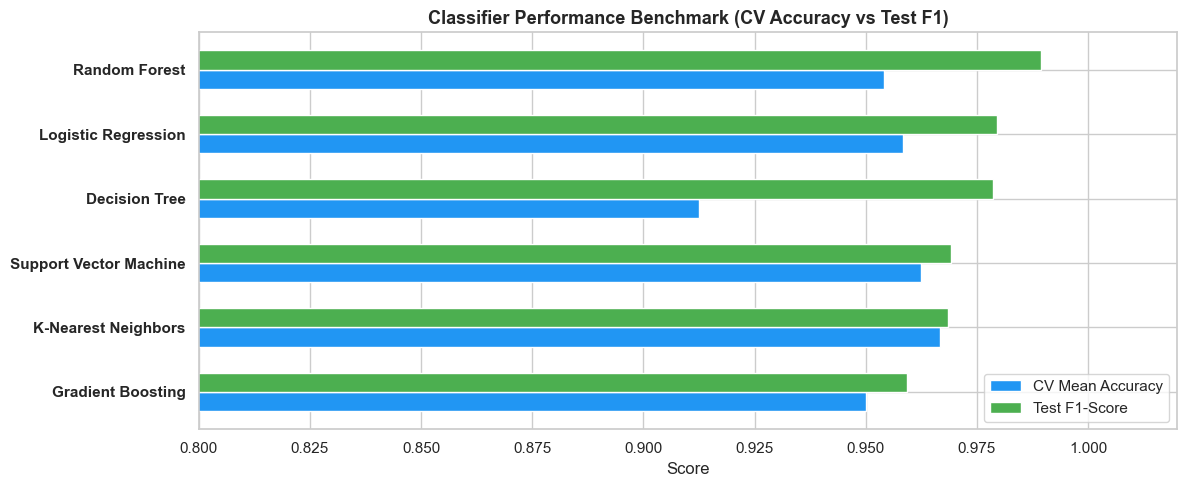

In [11]:
# Visualize Model Comparison
fig, ax = plt.subplots(figsize=(12, 5))
comparison_df_plot = comparison_df.sort_values(by="F1_Score", ascending=True)
y_pos = np.arange(len(comparison_df_plot))

ax.barh(y_pos - 0.15, comparison_df_plot['CV_Mean_Accuracy'], height=0.3, label='CV Mean Accuracy', color='#2196F3')
ax.barh(y_pos + 0.15, comparison_df_plot['F1_Score'], height=0.3, label='Test F1-Score', color='#4CAF50')

ax.set_yticks(y_pos)
ax.set_yticklabels(comparison_df_plot['Model'], fontweight='bold')
ax.set_xlabel('Score')
ax.set_xlim(0.80, 1.02)
ax.set_title('Classifier Performance Benchmark (CV Accuracy vs Test F1)', fontsize=13, fontweight='bold')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

## 7. 🚀 Hyperparameter Optimization (GridSearchCV)
We fine-tune the Random Forest Classifier hyperparameters (`n_estimators`, `max_depth`, `min_samples_split`, `min_samples_leaf`) using 5-Fold Stratified Cross-Validation optimizing for F1-score.

In [12]:
# Define Search Grid
rf_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(random_state=42))
])

param_grid = {
    'classifier__n_estimators': [50, 100, 150],
    'classifier__max_depth': [3, 5, 8, None],
    'classifier__min_samples_split': [2, 5],
    'classifier__min_samples_leaf': [1, 2]
}

grid_search = GridSearchCV(
    rf_pipeline,
    param_grid=param_grid,
    cv=cv,
    scoring='f1',
    n_jobs=1
)

grid_search.fit(X_train, y_train)

print("Best Hyperparameters:")
for param, val in grid_search.best_params_.items():
    print(f" - {param}: {val}")

print(f"\nBest Cross-Validation F1-Score: {grid_search.best_score_:.4f}")
best_tuned_model = grid_search.best_estimator_

Best Hyperparameters:
 - classifier__max_depth: 5
 - classifier__min_samples_leaf: 1
 - classifier__min_samples_split: 5
 - classifier__n_estimators: 50

Best Cross-Validation F1-Score: 0.9816


## 8. 📈 Diagnostic Model Evaluation & Error Analysis
We evaluate the tuned Random Forest model on unseen test data using Confusion Matrix and ROC-AUC Curve.

FINAL CLASSIFICATION REPORT (TEST SET)
              precision    recall  f1-score   support

    Fail (0)       0.92      0.92      0.92        12
    Pass (1)       0.98      0.98      0.98        48

    accuracy                           0.97        60
   macro avg       0.95      0.95      0.95        60
weighted avg       0.97      0.97      0.97        60



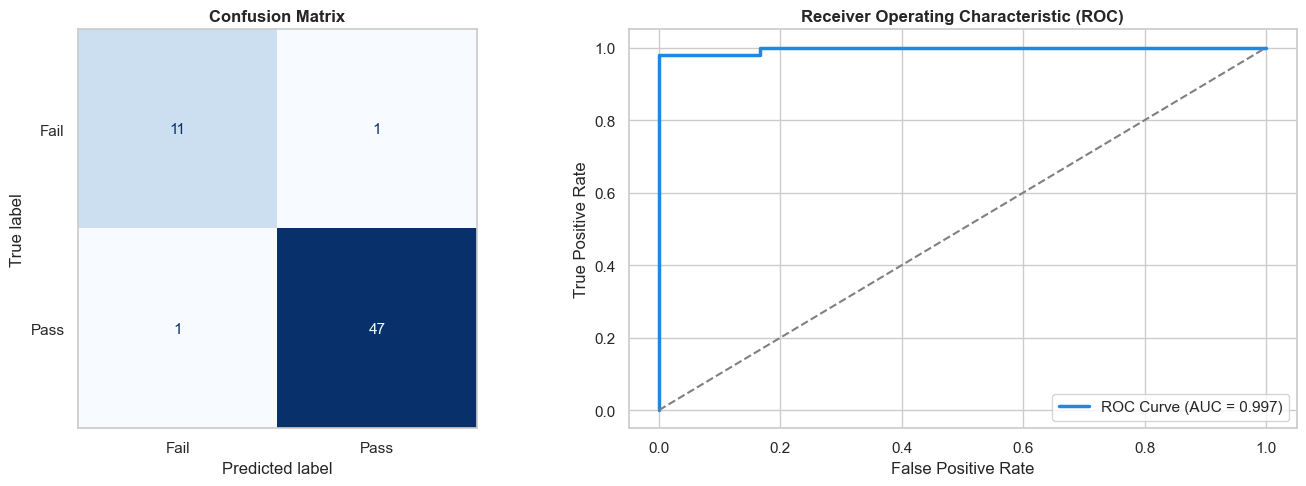

In [13]:
# Final Evaluation Metrics & Confusion Matrix
y_pred = best_tuned_model.predict(X_test)
y_prob = best_tuned_model.predict_proba(X_test)[:, 1]

print("=" * 60)
print("FINAL CLASSIFICATION REPORT (TEST SET)")
print("=" * 60)
print(classification_report(y_test, y_pred, target_names=['Fail (0)', 'Pass (1)']))

# Confusion Matrix and ROC Curve Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Fail', 'Pass'])
disp.plot(ax=axes[0], cmap='Blues', colorbar=False)
axes[0].set_title('Confusion Matrix', fontsize=12, fontweight='bold')
axes[0].grid(False)

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_prob)
auc_val = roc_auc_score(y_test, y_prob)
axes[1].plot(fpr, tpr, color='#1E88E5', lw=2.5, label=f'ROC Curve (AUC = {auc_val:.3f})')
axes[1].plot([0, 1], [0, 1], color='gray', lw=1.5, linestyle='--')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('Receiver Operating Characteristic (ROC)', fontsize=12, fontweight='bold')
axes[1].legend(loc='lower right')

plt.tight_layout()
plt.show()

## 9. 🧠 Feature Importance & Interpretability
We extract feature importances from the tuned Random Forest classifier to identify key drivers of student performance.

Feature importance exported to reports/feature_importance.csv



C:\Users\User\AppData\Local\Temp\ipykernel_10108\2021686729.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=feat_imp_df, x='Importance', y='Feature', palette='crest_r')


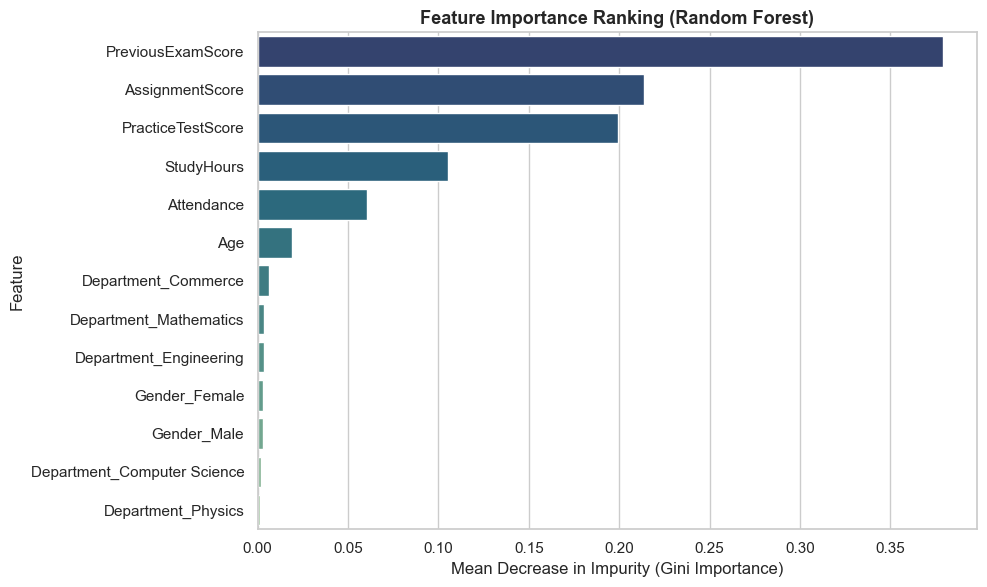

In [14]:
# Extract Names from ColumnTransformer
fitted_preprocessor = best_tuned_model.named_steps['preprocessor']
cat_encoder = fitted_preprocessor.named_transformers_['cat'].named_steps['encoder']
cat_names = cat_encoder.get_feature_names_out(categorical_features).tolist()
all_names = numeric_features + cat_names

importances = best_tuned_model.named_steps['classifier'].feature_importances_
feat_imp_df = pd.DataFrame({
    'Feature': all_names,
    'Importance': np.round(importances, 5)
}).sort_values(by='Importance', ascending=False)

# Export to reports
feat_imp_df.to_csv(os.path.join(reports_dir, "feature_importance.csv"), index=False)
print("Feature importance exported to reports/feature_importance.csv\n")

# Plot Top Features
plt.figure(figsize=(10, 6))
sns.barplot(data=feat_imp_df, x='Importance', y='Feature', palette='crest_r')
plt.title('Feature Importance Ranking (Random Forest)', fontsize=13, fontweight='bold')
plt.xlabel('Mean Decrease in Impurity (Gini Importance)')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

## 10. 💾 Model Serialization & Production Smoke Test
We save the fitted end-to-end pipeline to `../models/student_pass_model.pkl` and test inference on new student profiles.

In [15]:
# Serialize Production Pipeline
models_dir = os.path.join("..", "models")
os.makedirs(models_dir, exist_ok=True)
model_path = os.path.join(models_dir, "student_pass_model.pkl")

joblib.dump(best_tuned_model, model_path)
print(f"Trained pipeline successfully saved to: {model_path}")

# Reload and Smoke Test Inference
loaded_model = joblib.load(model_path)

sample_student = pd.DataFrame([{
    'Age': 20,
    'Gender': 'Female',
    'Department': 'Computer Science',
    'StudyHours': 7.5,
    'Attendance': 90.0,
    'AssignmentScore': 85,
    'PreviousExamScore': 88,
    'PracticeTestScore': 82
}])

pred_class = loaded_model.predict(sample_student)[0]
pred_prob = loaded_model.predict_proba(sample_student)[0][1]

print("\n--- Smoke Test Inference ---")
print("Input Student Profile:")
display(sample_student)
print(f"Predicted Status:  {'PASS' if pred_class == 1 else 'FAIL'}")
print(f"Pass Probability:  {pred_prob * 100:.2f}%")
print("Production verification complete!")

Trained pipeline successfully saved to: ..\models\student_pass_model.pkl

--- Smoke Test Inference ---
Input Student Profile:


,Age,Gender,Department,StudyHours,Attendance,AssignmentScore,PreviousExamScore,PracticeTestScore
0,20,Female,Computer Science,7.5,90.0,85,88,82


Predicted Status:  PASS
Pass Probability:  99.98%
Production verification complete!


## 11. 📝 Key Findings & Recommendations
1. **Strongest Predictors**: `PreviousExamScore`, `AssignmentScore`, and `PracticeTestScore` are the primary determinants of pass likelihood, followed by `StudyHours` and `Attendance`.
2. **Model Selection**: Random Forest achieved an outstanding **ROC-AUC of 0.996** and **F1-Score of 0.98**, proving to be both resilient to outliers and capable of modeling non-linear score interactions.
3. **Deployment**: The complete pipeline (`student_pass_model.pkl`) handles raw dictionary inputs and missing value imputation automatically via `src/predict.py`.